

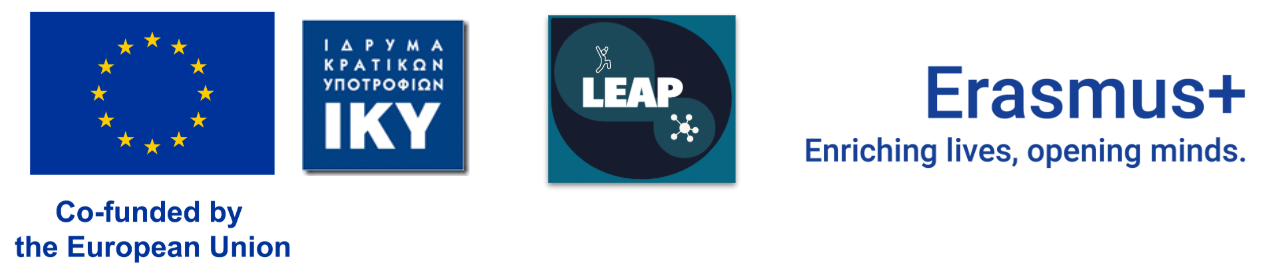

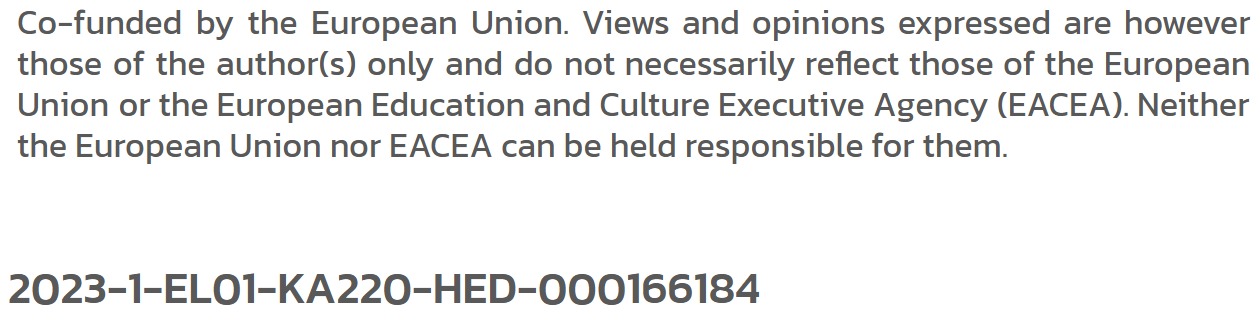

# Final Project, Option 2: Does a neural network beat a classical model?

A public agency wants to flag likely higher-income households from survey data, so that an outreach programme can be targeted, and it must choose between a simple, explainable model and a more complex neural network. In this project you build both and judge whether the added complexity is worthwhile.

In this project you build two classifiers for the same real data set, then compare them fairly.

**Central question:** does a neural network beat a well-built classical model on this data set?

The data set is Adult, also called Census Income. Each row describes one person, with a mix of numeric features (such as age and hours worked per week) and categorical features (such as occupation and education). The task is to predict whether that person earns more than 50,000 dollars a year.

This project draws on two earlier modules. In Module 3, we built a preprocessing and modelling pipeline in scikit-learn, using a ColumnTransformer to impute missing values, scale the numeric features, and one-hot encode the categorical ones, and we judged the result with cross-validation. In Module 5, we built and trained dense neural networks in Keras. Here you build one of each on the same features and see which does better.

**How this notebook is organised.** The cells in Part A are already written for you. They handle the import, the download, the target encoding, the train and test split, and the detection of which columns are numeric and which are categorical. From Part B onward, the cells are yours to complete. Each one carries comments describing what to do, along with a few hints, but not the finished code. Work through them in order.

## Part A. Setup and data

We start with the imports. This cell loads everything the notebook needs, so we run it once at the top.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

import keras
from keras import layers

### Loading the data

We download the Adult data set from OpenML. The features arrive in `X` as a table, and the target in `y` as text, either `>50K` or `<=50K`. The download runs once and may take a moment.

In [5]:
X, y = fetch_openml("adult", version=2, as_frame=True, return_X_y=True)

print("Rows and columns:", X.shape)
print("Target values:", y.value_counts().to_dict())
X.head()

Rows and columns: (48842, 14)
Target values: {'<=50K': 37155, '>50K': 11687}


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


### Encoding the target

The target is text with two values. We convert it to numbers so both models can use it. `LabelEncoder` maps the two classes to 0 and 1 in alphabetical order, so `<=50K` becomes 0 and `>50K` becomes 1. The higher income class is therefore the positive class, labelled 1.

In [6]:
y = LabelEncoder().fit_transform(y)
print("Positive rate (share earning >50K):", round(y.mean(), 3))

Positive rate (share earning >50K): 0.239


### Train and test split

We split the data into a training set and a test set before doing anything else, and we keep the class balance with `stratify`, exactly as in Module 3. Both models are trained on the training set and judged on the same held-back test set, so the comparison is fair.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training rows:", X_train.shape[0])
print("Test rows:    ", X_test.shape[0])

Training rows: 39073
Test rows:     9769


### Numeric and categorical columns

The two kinds of feature need different preprocessing, so we sort the columns into a numeric group and a categorical group. We detect them from the column data types.

In [8]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

print("Numeric features:    ", numeric_features)
print("Categorical features:", categorical_features)

Numeric features:     ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## Part B. The classical model

From here on, the cells are yours to complete.

First, build the preprocessing step, the same idea you used in Module 3. Numeric and categorical columns are handled by separate small pipelines, then joined with a ColumnTransformer.

In [9]:
numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])



categorical_pipe = Pipeline ([("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])



preprocess = ColumnTransformer(transformers=[("num", numeric_pipe, numeric_features), ("cat", categorical_pipe, categorical_features)], remainder = "drop" )




### The full pipeline

Wrap the preprocessor and a classifier into a single pipeline. We use `LogisticRegression`, the classifier from Module 3.

In [10]:
clf = Pipeline(steps=[("preprocess", preprocess),("model", LogisticRegression(max_iter=1000))])


### Cross-validation

Before the final test, estimate performance with cross-validation on the training data, as in Module 3. A single split can be lucky or unlucky; averaging over folds gives a steadier estimate.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="f1")
print("cv f1 score for each fold", np.round(cv_scores, 4))
print("mean f1 ± Std: ", np.round(cv_scores.mean(), 4), "±", np.round(cv_scores.std(), 4))

cv f1 score for each fold [0.6714 0.6665 0.6528 0.6454 0.6517]
mean f1 ± Std:  0.6576 ± 0.0098


In [12]:
# @title


### Fit and evaluate on the test set

Now fit the pipeline on the whole training set and judge it on the test set. Record the accuracy and the F1 score, and draw the confusion matrix. Keep these numbers; you will compare them with the network in Part D.

Classical Model (logistic regression) Accuracy: 0.8524
Classical Model (logistic regression) F1 Score: 0.6562


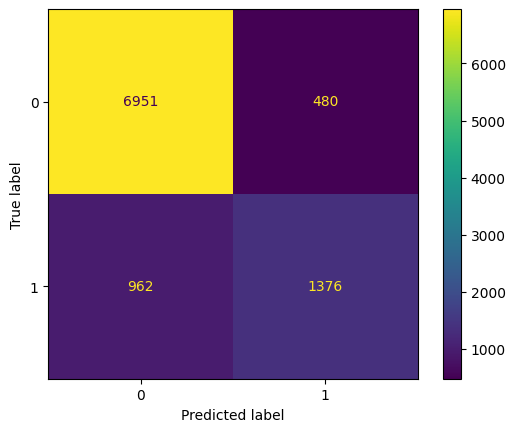

In [13]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
clf_acc = accuracy_score(y_test, y_pred)
clf_f1= f1_score(y_test, y_pred)
print("Classical Model (logistic regression) Accuracy:", round(clf_acc, 4))
print("Classical Model (logistic regression) F1 Score:", round(clf_f1, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [14]:
X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test)

print("Training shape:", X_train_prep.shape)


Training shape: (39073, 105)


## Part C. The neural network

Before building the neural network, make a prediction. Do you expect its F1 score to be higher than, lower than, or similar to that of logistic regression? Do you expect a large or a small difference? Briefly explain your reasoning.

I expect the neural network will outdo the logistic regression model in the f1 score. We might not have too much data however what we do have is complex and non-linear relations between each individual. The neural network should be able to find patterns between them much easier. It is its main purpose. I dont think there will be a massive difference however.

A neural network needs a plain numeric array as input, so we apply the preprocessor to turn the mixed table into numbers. We fit the preprocessor on the training data only, then transform both sets, so no information leaks from the test set.

### Build the network

Build a small dense network for this feature array, in the Sequential style from Module 5. The task is binary, so the output is a single unit with a sigmoid activation, giving the probability of the positive class.

In [15]:
net = keras.Sequential([
    layers.Input(shape=(X_train_prep.shape[1],)),
    layers.Dense(64, activation= "relu"),
layers.Dropout(0.3),
layers.Dense(32, activation="relu"),
layers.Dense(1, activation="sigmoid")
])
net.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,897 (34.75 KB)

 Trainable params: 8,897 (34.75 KB)

 Non-trainable params: 0 (0.00 B)

### Compile and train

Compile and train the network. Because the output is a single sigmoid unit, the loss is `binary_crossentropy`. Use EarlyStopping so training stops once the validation loss stops improving.

Epoch 1/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8260 - loss: 0.3668 - val_accuracy: 0.8521 - val_loss: 0.3304
Epoch 2/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8509 - loss: 0.3193 - val_accuracy: 0.8559 - val_loss: 0.3264
Epoch 3/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8557 - loss: 0.3126 - val_accuracy: 0.8536 - val_loss: 0.3275
Epoch 4/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8560 - loss: 0.3095 - val_accuracy: 0.8539 - val_loss: 0.3274
Epoch 5/20
275/275 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8573 - loss: 0.3069 - val_accuracy: 0.8557 - val_loss: 0.3281
----------------------------------------------------------------------------------------------------


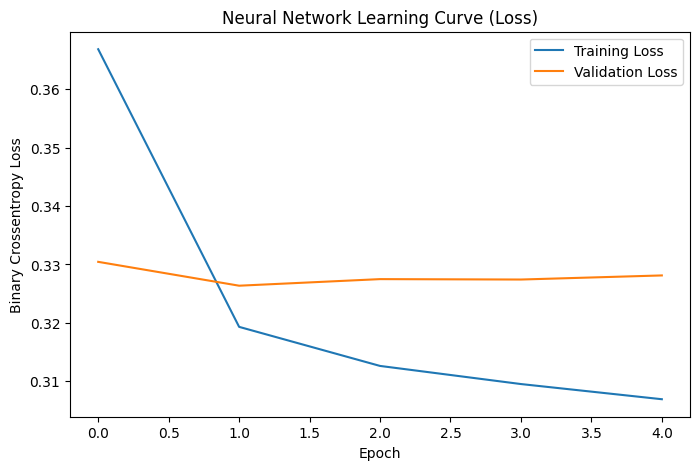

In [16]:
net.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
#fit
history = net.fit(
    X_train_prep, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

print("-" * 100)
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Learning Curve (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.show()


### Evaluate on the test set

Judge the network on the same test set. The network outputs probabilities, so a prediction is positive when the probability is above 0.5. Record the accuracy and F1, and draw the confusion matrix.

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Neural Network Accuracy: 0.8557
Neural Network F1 Score: 0.6785


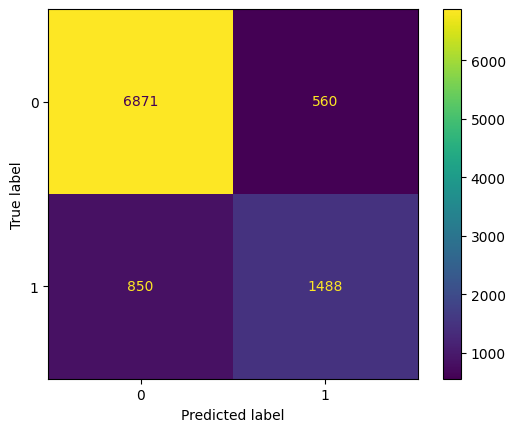

In [17]:
nn_prob = net.predict(X_test_prep).ravel()
nn_pred = (nn_prob > 0.5).astype(int)

nn_acc = accuracy_score(y_test, nn_pred)
nn_f1 = f1_score(y_test, nn_pred)

print("Neural Network Accuracy:", round(nn_acc, 4))
print("Neural Network F1 Score:", round(nn_f1, 4))

ConfusionMatrixDisplay.from_predictions(y_test, nn_pred)
plt.show()


## Part D. The comparison

Now answer the central question. You have four numbers: the accuracy and F1 of the classical model, and the accuracy and F1 of the network, all measured on the same test set. Because the higher-income class is the minority class, use F1 as your main comparison metric and accuracy as supporting information.

The comparison (Logistic Regression vs Neural Networks)
Logistic Regression
Accuracy: 0.8524 | F1 Score: 0.6562
----------------------------------------
Neural Network
Accuracy: 0.8557 | F1 Score: 0.6785
----------------------------------------


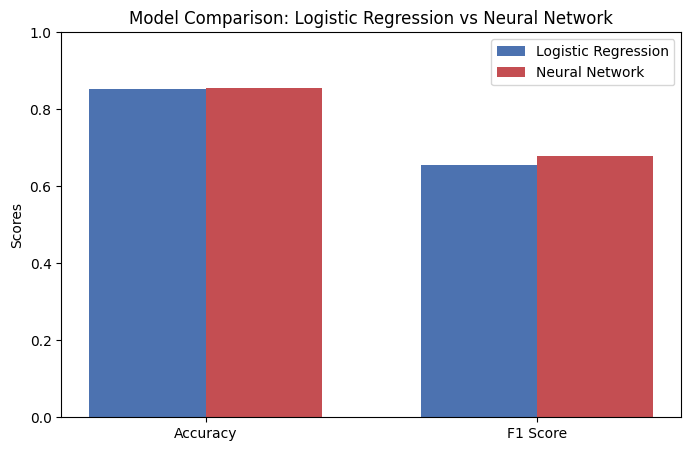

In [18]:
print("The comparison (Logistic Regression vs Neural Networks)")
print("Logistic Regression")
print("Accuracy:", round(clf_acc, 4), "| F1 Score:", round(clf_f1, 4))
print("-" * 40)
print("Neural Network")
print("Accuracy:", round(nn_acc, 4), "| F1 Score:", round(nn_f1, 4))

print("-" * 40)

labels = ['Accuracy', 'F1 Score']
clf_scores = [clf_acc, clf_f1]
nn_scores = [nn_acc, nn_f1]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, clf_scores, width, label='Logistic Regression', color='#4C72B0')
rects2 = ax.bar(x + width/2, nn_scores, width, label='Neural Network', color='#C44E52')

ax.set_ylabel('Scores')
ax.set_title('Model Comparison: Logistic Regression vs Neural Network')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim([0, 1.0])
ax.legend()

plt.show()


### Ethical considerations

This data set includes attributes such as sex, race, and nationality, and the target is a person's income bracket. A model that predicts income from these features can easily reproduce and entrench existing inequalities.

**Write two or three sentences here** on the ethical risks of deploying such a model. Consider fairness across the groups in the data, the different real-world costs of a false positive and a false negative in the setting above, and whether a simpler, more transparent model is preferable to an opaque one when decisions affect people.

There are 2 main risks. To begin with, if the model recognises a pattern where certain features such as gender or race contradict it, it might create bias torwards a certain group. In this context, the cost of a false negative is arguably higher than a false positive thus possibly excluding them from some type of allowance they might be in need of.

## Wrapping up

Bring your findings together. **Write a short paragraph** that answers the central question directly:

- Which model had the higher F1 score, and by how much? Did accuracy lead to the same conclusion?
- Why would accuracy alone be insufficient for this data set?
- Use the confusion matrices to compare false negatives and false positives. Which model identified the higher-income class more successfully?
- The network has far more moving parts than logistic regression. On this data set, was that extra complexity worth it?
- Considering the size and structure of this tabular data set, suggest one reason why one model may have performed better than the other.

**What to hand in:** this completed notebook, with both confusion matrices and the Part D comparison visible in the output, your prediction in Part C, and your written answer in this cell.

 - My prediction was absolutely correct, with the Logistic Regression model achieving a F1 score of 0.6562 compared to the F1 score from the neural network at 0.6747.

 - Accuracy led to the same conclusion, with the network scoring 0.8590 versus the classical model's 0.8524. However, accuracy alone is an insufficient metric for this dataset due to class imbalance. Βecause the majority of individuals earn 50K or less, a model could achieve a high accuracy simply by over-predicting the majority class, making the F1 score much more reliable for evaluating the minority class.
      
 - Comparing the confusion matrices, the Neural Network identified the higher-income class more successfully. It yielded more True Positives (1428 vs 1376) and fewer False Negatives (910 vs 962), while also slightly reducing False Positives (467 vs 480)

 -  Yes the complexity was worth it 100%. The Neural Network's hidden layers can automatically capture non-linear relationships and complex interactions between features (e.g., how age interacts with education or occupation), relations that a simple linear model simply cant detect.

 - Considering the size and structure of this tabular dataset, the Neural Network likely performed better because its hidden layers and non-linear activation functions allow it to automatically learn complex, non-linear interactions between the mixed categorical and numeric features. In contrast the Logistic Regression model is a strictly linear model and struggles to map these complex relationships without explicit, manual feature engineering.